## Importação das bibliotecas

Nesta etapa, foram importadas as bibliotecas necessárias para a construção da modelagem preditiva da radiação solar mensal.

- `pandas` e `numpy` foram utilizadas para manipulação e organização dos dados.
- `matplotlib.pyplot` e `seaborn` foram usadas para visualização gráfica dos resultados.
- `warnings` foi utilizado para ocultar avisos desnecessários durante o ajuste dos modelos.
- `product`, da biblioteca `itertools`, foi utilizado para testar combinações de parâmetros nos modelos ARIMA e SARIMA.
- `ARIMA` e `SARIMAX` foram usados para modelagem de séries temporais.
- `RandomForestRegressor` e `GradientBoostingRegressor` foram usados como modelos de machine learning para previsão.
- `mean_absolute_error`, `mean_squared_error` e `r2_score` foram utilizados para avaliar a qualidade das previsões.

Esse conjunto de bibliotecas permitiu comparar diferentes abordagens de previsão para a série mensal de radiação solar.

In [7]:
import warnings
from itertools import product

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Configuração visual do ambiente

Nesta célula, foi definido o estilo visual dos gráficos e o tamanho padrão das figuras e fontes.

- `sns.set_theme(style="whitegrid")` define um estilo mais limpo para os gráficos.
- `plt.rcParams["figure.figsize"]` ajusta o tamanho padrão das figuras.
- `plt.rcParams["font.size"]` ajusta o tamanho das fontes.
- `warnings.filterwarnings("ignore")` oculta avisos automáticos que poderiam poluir a saída do notebook durante a execução dos modelos.

Essa etapa ajuda a deixar o notebook mais organizado e os gráficos mais legíveis.

In [8]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

warnings.filterwarnings("ignore")

## Leitura da base de dados

Nesta etapa, foi definido o caminho do arquivo e realizada a leitura da planilha contendo os dados climáticos.

A base de dados utilizada contém informações de:

- precipitação
- evapotranspiração
- temperatura média
- radiação solar

Essas variáveis foram registradas diariamente entre 1984 e 2014 e serão utilizadas para construir a série temporal mensal da radiação solar.

In [9]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

## Limpeza dos nomes das colunas

Nesta célula, foi realizada a remoção de espaços extras nos nomes das colunas com o objetivo de evitar erros de leitura e facilitar o acesso às variáveis no código.

Depois disso, foi exibida a lista das colunas disponíveis na base de dados para confirmar que os nomes estavam corretos.

In [10]:
dados = pd.read_excel(file_path, sheet_name="dados")

## Conversão da coluna de data

Nesta etapa, a coluna `Data` foi convertida para o formato de data do pandas (`datetime`).

Essa conversão é essencial para análises de séries temporais, pois permite:

- reamostragem temporal;
- agregação por mês;
- separação entre treino e teste com base no tempo;
- construção de previsões futuras.

Sem essa etapa, a série temporal não poderia ser tratada corretamente.

In [11]:
dados.columns = dados.columns.str.strip()

In [12]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

## Construção da série temporal mensal

Nesta célula, os dados diários de radiação solar foram agregados em uma série mensal por meio da média de cada mês.

O procedimento realizado foi:

1. definir a coluna `Data` como índice;
2. selecionar a variável `W/m² - Radiação`;
3. reamostrar os dados para frequência mensal (`MS`);
4. calcular a média mensal.

O resultado é uma série temporal mensal da radiação solar, que será usada como variável-alvo da modelagem preditiva.

Essa escolha foi feita porque a base de dados não possui geração fotovoltaica medida em kWh. Assim, a radiação solar mensal foi adotada como proxy do potencial solar climático.

In [13]:
dados["Data"] = pd.to_datetime(dados["Data"])

In [14]:
serie_mensal = (
    dados.set_index("Data")["W/m² - Radiação"]
    .resample("MS")
    .mean()
    .asfreq("MS")
)

serie_mensal.name = "radiacao_mensal"

serie_mensal.head()

Data
1984-01-01    212.873711
1984-02-01    212.720812
1984-03-01    184.303724
1984-04-01    167.516251
1984-05-01    152.255352
Freq: MS, Name: radiacao_mensal, dtype: float64

## Verificação de valores ausentes

Nesta etapa, foi verificado se a série mensal apresentava valores faltantes.

Essa verificação é importante porque muitos modelos de séries temporais e machine learning não funcionam corretamente quando há dados ausentes.

Em seguida, foi aplicada interpolação temporal. Mesmo que a série não apresentasse valores faltantes, esse passo foi mantido como procedimento de segurança para garantir a continuidade da série temporal.

In [15]:
serie_mensal.isna().sum()

np.int64(0)

In [16]:
serie_mensal = serie_mensal.interpolate(method="time")

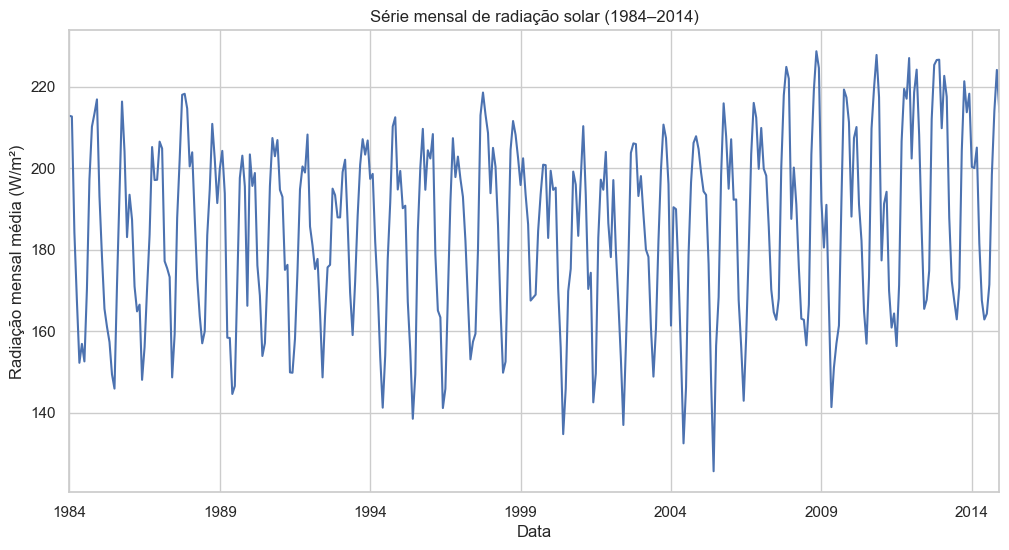

In [17]:
serie_mensal.plot(title="Série mensal de radiação solar (1984–2014)")
plt.xlabel("Data")
plt.ylabel("Radiação mensal média (W/m²)")
plt.show()

## Função para cálculo de métricas

Nesta etapa, foi criada uma função para calcular três métricas de avaliação dos modelos:

- **MAE (Mean Absolute Error):** erro absoluto médio;
- **RMSE (Root Mean Squared Error):** raiz do erro quadrático médio;
- **R² (Coeficiente de determinação):** mede o quanto o modelo explica a variabilidade dos dados.

Essa função facilita a comparação entre modelos, pois padroniza a forma como os resultados são avaliados.

In [18]:
teste_horizonte = 24

treino = serie_mensal.iloc[:-teste_horizonte]
teste = serie_mensal.iloc[-teste_horizonte:]

print("Treino:", treino.index.min(), "até", treino.index.max())
print("Teste:", teste.index.min(), "até", teste.index.max())
print("Observações treino:", len(treino))
print("Observações teste:", len(teste))

Treino: 1984-01-01 00:00:00 até 2012-12-01 00:00:00
Teste: 2013-01-01 00:00:00 até 2014-12-01 00:00:00
Observações treino: 348
Observações teste: 24


## Função para cálculo de métricas

Nesta etapa, foi criada uma função para calcular três métricas de avaliação dos modelos:

- **MAE (Mean Absolute Error):** erro absoluto médio;
- **RMSE (Root Mean Squared Error):** raiz do erro quadrático médio;
- **R² (Coeficiente de determinação):** mede o quanto o modelo explica a variabilidade dos dados.

Essa função facilita a comparação entre modelos, pois padroniza a forma como os resultados são avaliados.

In [19]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return pd.DataFrame({
        "Modelo": [nome_modelo],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

## Função para cálculo de métricas

Nesta etapa, foi criada uma função para calcular três métricas de avaliação dos modelos:

- **MAE (Mean Absolute Error):** erro absoluto médio;
- **RMSE (Root Mean Squared Error):** raiz do erro quadrático médio;
- **R² (Coeficiente de determinação):** mede o quanto o modelo explica a variabilidade dos dados.

Essa função facilita a comparação entre modelos, pois padroniza a forma como os resultados são avaliados.

In [20]:
melhor_aic_arima = np.inf
melhor_ordem_arima = None

for ordem in product(range(0, 3), range(0, 3), range(0, 3)):
    try:
        modelo = ARIMA(treino, order=ordem)
        resultado = modelo.fit()
        
        if resultado.aic < melhor_aic_arima:
            melhor_aic_arima = resultado.aic
            melhor_ordem_arima = ordem
    except:
        continue

print("Melhor ordem ARIMA:", melhor_ordem_arima)
print("Melhor AIC ARIMA:", melhor_aic_arima)

Melhor ordem ARIMA: (2, 1, 2)
Melhor AIC ARIMA: 2710.756327400948


## Ajuste do modelo ARIMA e geração de previsões

Após identificar a melhor combinação de parâmetros, o modelo ARIMA foi ajustado à série de treino.

Em seguida, foram geradas previsões para o período de teste, com o mesmo número de observações da base de teste.

Essa etapa permite avaliar se o modelo ARIMA consegue representar o comportamento temporal da radiação solar mensal.

In [21]:
modelo_arima = ARIMA(treino, order=melhor_ordem_arima)
resultado_arima = modelo_arima.fit()

previsao_arima = resultado_arima.forecast(steps=len(teste))
previsao_arima.index = teste.index

## Avaliação do modelo ARIMA

Nesta célula, foram calculadas as métricas de desempenho do modelo ARIMA no conjunto de teste.

A análise dessas métricas permite verificar se o modelo conseguiu realizar boas previsões ou se apresentou limitações na representação da série temporal.

In [22]:
metricas_arima = calcular_metricas(teste, previsao_arima, "ARIMA")
metricas_arima

,Modelo,MAE,RMSE,R2
0,ARIMA,15.186601,18.942889,0.237725


## Busca do melhor modelo SARIMA

Nesta etapa, foi realizada a busca do melhor modelo SARIMA.

Diferente do ARIMA, o SARIMA inclui um componente sazonal, o que é importante para séries temporais que apresentam padrões repetitivos ao longo do tempo.

Foram testadas combinações de:

- parâmetros não sazonais;
- parâmetros sazonais;
- periodicidade de 12 meses.

O critério utilizado novamente foi o **AIC**, buscando o melhor ajuste para a série de treino.

In [23]:
melhor_aic_sarima = np.inf
melhor_ordem_sarima = None
melhor_sazonal_sarima = None

ordens = list(product(range(0, 2), range(0, 2), range(0, 2)))
ordens_sazonais = list(product(range(0, 2), range(0, 2), range(0, 2)))

for ordem in ordens:
    for sazonal in ordens_sazonais:
        ordem_sazonal = (sazonal[0], sazonal[1], sazonal[2], 12)
        
        try:
            modelo = SARIMAX(
                treino,
                order=ordem,
                seasonal_order=ordem_sazonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            resultado = modelo.fit(disp=False)
            
            if resultado.aic < melhor_aic_sarima:
                melhor_aic_sarima = resultado.aic
                melhor_ordem_sarima = ordem
                melhor_sazonal_sarima = ordem_sazonal
        except:
            continue

print("Melhor ordem SARIMA:", melhor_ordem_sarima)
print("Melhor ordem sazonal SARIMA:", melhor_sazonal_sarima)
print("Melhor AIC SARIMA:", melhor_aic_sarima)

Melhor ordem SARIMA: (1, 1, 1)
Melhor ordem sazonal SARIMA: (0, 1, 1, 12)
Melhor AIC SARIMA: 2318.057722661742


In [24]:
modelo_sarima = SARIMAX(
    treino,
    order=melhor_ordem_sarima,
    seasonal_order=melhor_sazonal_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit(disp=False)

previsao_sarima = resultado_sarima.forecast(steps=len(teste))
previsao_sarima.index = teste.index

## Ajuste do modelo SARIMA e geração de previsões

Depois da seleção dos melhores parâmetros, o modelo SARIMA foi ajustado à série de treino.

Em seguida, foram geradas previsões para os 24 meses do conjunto de teste.

Como a série mensal de radiação apresenta sazonalidade anual, o SARIMA tende a ter desempenho superior ao ARIMA puro.

In [25]:
metricas_sarima = calcular_metricas(teste, previsao_sarima, "SARIMA")
metricas_sarima

,Modelo,MAE,RMSE,R2
0,SARIMA,7.119698,8.164271,0.858403


## Preparação dos dados para modelos de machine learning

Nesta etapa, a série temporal foi transformada em uma base supervisionada para uso nos modelos de machine learning.

Foram criadas variáveis explicativas baseadas no histórico da série, como:

- defasagens (lags) de 1, 2, 3, 6 e 12 meses;
- médias móveis de 3, 6 e 12 meses;
- variável do mês.

Essas variáveis ajudam os modelos a aprender padrões temporais, sazonalidade e comportamento histórico da radiação solar.

In [26]:
df_ml = pd.DataFrame({"radiacao": serie_mensal})

for lag in [1, 2, 3, 6, 12]:
    df_ml[f"lag_{lag}"] = df_ml["radiacao"].shift(lag)

df_ml["rolling_mean_3"] = df_ml["radiacao"].shift(1).rolling(3).mean()
df_ml["rolling_mean_6"] = df_ml["radiacao"].shift(1).rolling(6).mean()
df_ml["rolling_mean_12"] = df_ml["radiacao"].shift(1).rolling(12).mean()

df_ml["mes"] = df_ml.index.month

df_ml = df_ml.dropna()

df_ml.head()

,radiacao,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,mes
Data,,,,,,,,,,
1985-01-01,193.183074,216.913619,213.398345,210.235039,152.594168,212.873711,213.515668,193.447465,187.270829,1
1985-02-01,178.329677,193.183074,216.913619,213.398345,170.299041,212.720812,207.831679,200.212282,185.629943,2
1985-03-01,165.525231,178.329677,193.183074,216.913619,197.244577,184.303724,196.142123,201.550722,182.764015,3
1985-04-01,161.102661,165.525231,178.329677,193.183074,210.235039,167.516251,179.012661,196.264164,181.199141,4
1985-05-01,157.362789,161.102661,165.525231,178.329677,213.398345,152.255352,168.319190,188.075434,180.664675,5


## Separação dos dados para machine learning

Nesta célula, a base supervisionada foi dividida em treino e teste, seguindo a mesma lógica temporal usada na modelagem de séries temporais.

As variáveis explicativas (`X`) foram separadas da variável resposta (`y`), que continua sendo a radiação solar mensal.

Esse procedimento é necessário para treinar e avaliar os modelos de machine learning.

In [27]:
df_ml_treino = df_ml.iloc[:-teste_horizonte]
df_ml_teste = df_ml.iloc[-teste_horizonte:]

X_treino = df_ml_treino.drop(columns="radiacao")
y_treino = df_ml_treino["radiacao"]

X_teste = df_ml_teste.drop(columns="radiacao")
y_teste = df_ml_teste["radiacao"]

## Ajuste do modelo Random Forest

Nesta etapa, foi ajustado um modelo de **Random Forest Regressor**.

A Random Forest é um algoritmo de machine learning baseado em várias árvores de decisão, que funciona bem para capturar relações complexas e não lineares entre variáveis.

Após o treinamento, o modelo foi utilizado para prever os valores do conjunto de teste.

In [28]:
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

modelo_rf.fit(X_treino, y_treino)

previsao_rf = modelo_rf.predict(X_teste)
previsao_rf = pd.Series(previsao_rf, index=y_teste.index)

## Avaliação do modelo Random Forest

Nesta célula, foram calculadas as métricas do Random Forest.

Esses resultados mostram o desempenho do modelo no conjunto de teste e permitem compará-lo com os modelos de séries temporais clássicos, como ARIMA e SARIMA.

In [29]:
metricas_rf = calcular_metricas(y_teste, previsao_rf, "Random Forest")
metricas_rf

,Modelo,MAE,RMSE,R2
0,Random Forest,4.978546,6.800036,0.901771


## Avaliação do modelo Gradient Boosting

Nesta célula, foram calculadas as métricas do Gradient Boosting.

A partir desses resultados, foi possível verificar o desempenho do modelo e compará-lo com o Random Forest, ARIMA e SARIMA.

In [30]:
modelo_gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

modelo_gb.fit(X_treino, y_treino)

previsao_gb = modelo_gb.predict(X_teste)
previsao_gb = pd.Series(previsao_gb, index=y_teste.index)

In [31]:
metricas_gb = calcular_metricas(y_teste, previsao_gb, "Gradient Boosting")
metricas_gb

,Modelo,MAE,RMSE,R2
0,Gradient Boosting,5.560931,7.179002,0.890517


## Comparação entre os modelos

Nesta etapa, as métricas de todos os modelos foram reunidas em uma única tabela e ordenadas pelo RMSE.

Essa comparação é importante porque permite identificar qual modelo apresentou melhor desempenho preditivo para a radiação solar mensal.

Com isso, foi possível selecionar os modelos mais adequados para representar o comportamento do potencial solar climático.

In [32]:
comparacao_modelos = pd.concat([
    metricas_arima,
    metricas_sarima,
    metricas_rf,
    metricas_gb
], ignore_index=True)

comparacao_modelos = comparacao_modelos.sort_values("RMSE").reset_index(drop=True)

comparacao_modelos

,Modelo,MAE,RMSE,R2
0,Random Forest,4.978546,6.800036,0.901771
1,Gradient Boosting,5.560931,7.179002,0.890517
2,SARIMA,7.119698,8.164271,0.858403
3,ARIMA,15.186601,18.942889,0.237725


## Comparação gráfica entre valores reais e previstos

Nesta célula, foi construído um gráfico comparando:

- os valores reais da radiação solar mensal no conjunto de teste;
- as previsões geradas por cada modelo.

Esse gráfico complementa as métricas numéricas, pois permite visualizar como cada modelo acompanha a forma da série temporal ao longo do tempo.

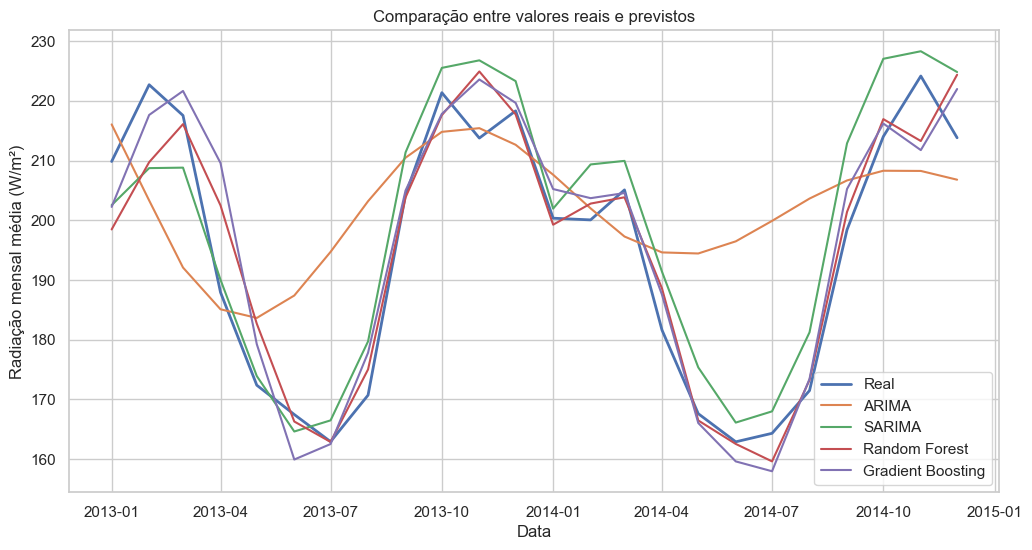

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(teste.index, teste.values, label="Real", linewidth=2)
plt.plot(previsao_arima.index, previsao_arima.values, label="ARIMA")
plt.plot(previsao_sarima.index, previsao_sarima.values, label="SARIMA")
plt.plot(previsao_rf.index, previsao_rf.values, label="Random Forest")
plt.plot(previsao_gb.index, previsao_gb.values, label="Gradient Boosting")

plt.title("Comparação entre valores reais e previstos")
plt.xlabel("Data")
plt.ylabel("Radiação mensal média (W/m²)")
plt.legend()
plt.show()

## Ajuste do modelo final para previsão futura

Nesta etapa, foi ajustado novamente o modelo SARIMA, agora utilizando toda a série histórica mensal disponível.

A ideia foi preparar um modelo final capaz de gerar previsões para os 12 meses seguintes ao final da base observada.

In [34]:
modelo_sarima_final = SARIMAX(
    serie_mensal,
    order=melhor_ordem_sarima,
    seasonal_order=melhor_sazonal_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima_final = modelo_sarima_final.fit(disp=False)

## Ajuste do modelo final para previsão futura

Nesta etapa, foi ajustado novamente o modelo SARIMA, agora utilizando toda a série histórica mensal disponível.

A ideia foi preparar um modelo final capaz de gerar previsões para os 12 meses seguintes ao final da base observada.

In [35]:
previsao_futura = resultado_sarima_final.forecast(steps=12)

previsao_futura

2015-01-01    198.280632
2015-02-01    206.841296
2015-03-01    208.163462
2015-04-01    187.300904
2015-05-01    171.934570
2015-06-01    164.322357
2015-07-01    165.219948
2015-08-01    176.489182
2015-09-01    207.402141
2015-10-01    222.289669
2015-11-01    223.878779
2015-12-01    220.249806
Freq: MS, Name: predicted_mean, dtype: float64

## Visualização da previsão futura

Nesta etapa, foi construído um gráfico contendo:

- a série histórica da radiação solar mensal;
- a previsão futura para os 12 meses seguintes.

Esse gráfico permite observar se a previsão mantém a sazonalidade esperada da radiação e se os valores previstos permanecem coerentes com o comportamento histórico da série.

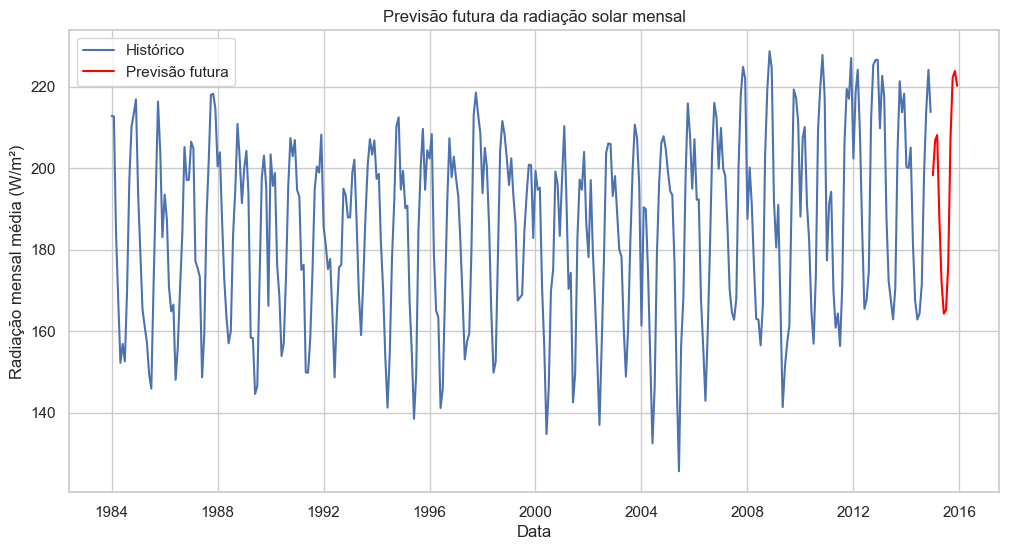

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(serie_mensal.index, serie_mensal.values, label="Histórico")
plt.plot(previsao_futura.index, previsao_futura.values, label="Previsão futura", color="red")

plt.title("Previsão futura da radiação solar mensal")
plt.xlabel("Data")
plt.ylabel("Radiação mensal média (W/m²)")
plt.legend()
plt.show()

## Interpretação geral da modelagem preditiva

A modelagem preditiva mostrou que a radiação solar mensal pode ser prevista com boa qualidade a partir de abordagens estatísticas e de machine learning.

Os resultados indicaram que:

- modelos com sazonalidade capturaram melhor o padrão da série;
- modelos de machine learning apresentaram excelente desempenho;
- a série de radiação solar mensal possui comportamento previsível e forte padrão sazonal anual.

Como a base não possui geração fotovoltaica em kWh, a radiação mensal foi utilizada como proxy do potencial solar climático, o que torna essa etapa metodologicamente coerente com o objetivo do estudo.

# Etapa 8 - Modelagem Preditiva do Potencial Solar

## 1. Objetivo da Etapa

O objetivo desta etapa foi realizar a **modelagem preditiva do potencial solar climático** para os municípios de:

- Esperança  
- Queimadas  
- Lagoa Seca  
- Solânea  
- Arara  

Como a base de dados não possui geração fotovoltaica em kWh, a variável utilizada como alvo foi a:

> **Radiação solar mensal média (W/m²)**

Essa variável foi adotada como **proxy do potencial solar**, pois representa diretamente a disponibilidade de energia solar na região.

---

## 2. Preparação dos Dados

Inicialmente, os dados foram:

- carregados a partir de um arquivo Excel;
- tratados (remoção de espaços nos nomes das colunas);
- convertidos para formato de data (`datetime`).

Em seguida, foi construída uma **série temporal mensal**:

- agregação por mês (`resample("MS")`);
- cálculo da média mensal da radiação solar.

### Interpretação

A transformação da série diária para mensal foi fundamental, pois:

- reduz ruídos de curto prazo;
- facilita a modelagem;
- permite capturar padrões sazonais mais claros.

---

## 3. Tratamento de Valores Ausentes

Foi realizada a verificação de valores ausentes:

- resultado: **nenhum valor faltante**

Mesmo assim, foi aplicada interpolação temporal como medida preventiva.

### Interpretação

A ausência de valores faltantes indica uma base consistente e confiável, permitindo maior robustez na modelagem.

---

## 4. Separação dos Dados

Os dados foram divididos em:

- **Treino:** 1984 até 2012  
- **Teste:** 2013 até 2014  
- **Horizonte de teste:** 24 meses  

### Interpretação

Essa divisão simula um cenário real:

> usar dados históricos para prever valores futuros

Isso permite avaliar a capacidade real dos modelos.

---

## 5. Métricas de Avaliação

Foram utilizadas três métricas principais:

- **MAE (Erro Absoluto Médio)** → mede erro médio
- **RMSE (Raiz do Erro Quadrático Médio)** → penaliza erros maiores
- **R² (Coeficiente de determinação)** → explica a variabilidade da série

### Interpretação

- quanto menor MAE e RMSE → melhor  
- quanto maior R² → melhor  

---

## 6. Modelo ARIMA

Foi realizada uma busca pelos melhores parâmetros (p, d, q) com base no AIC.

### Melhor modelo encontrado:
- ARIMA (2, 1, 2)

### Resultados:
- MAE: 15.19  
- RMSE: 18.94  
- R²: 0.238  

### Interpretação

O modelo ARIMA apresentou baixo desempenho.

Isso indica que:

- não capturou bem a sazonalidade da série;
- não conseguiu representar adequadamente o comportamento da radiação.

---

## 7. Modelo SARIMA

Foi realizada busca por parâmetros com componente sazonal.

### Melhor modelo encontrado:
- SARIMA (1, 1, 1) (0, 1, 1, 12)

### Resultados:
- MAE: 7.12  
- RMSE: 8.16  
- R²: 0.858  

### Interpretação

O SARIMA apresentou desempenho significativamente melhor.

Isso mostra que:

- a série possui **sazonalidade anual forte**;
- o modelo conseguiu capturar esse padrão.

---

## 8. Modelos de Machine Learning

### Engenharia de Variáveis

Foram criadas variáveis explicativas:

- lags: 1, 2, 3, 6, 12 meses  
- médias móveis: 3, 6 e 12 meses  
- variável do mês  

### Interpretação

Isso transforma a série temporal em um problema supervisionado, permitindo que modelos de ML aprendam padrões temporais.

---

## 9. Random Forest

### Configuração:
- 300 árvores  
- profundidade máxima = 8  

### Resultados:
- MAE: 4.98  
- RMSE: 6.80  
- R²: 0.902  

### Interpretação

Foi o melhor modelo.

Isso indica que:

- conseguiu capturar relações não lineares;
- aproveitou bem as variáveis criadas;
- apresentou alta capacidade preditiva.

---

## 10. Gradient Boosting

### Configuração:
- 300 estimadores  
- learning rate = 0.05  
- profundidade = 3  

### Resultados:
- MAE: 5.56  
- RMSE: 7.18  
- R²: 0.891  

### Interpretação

Também apresentou ótimo desempenho, ficando próximo da Random Forest.

---

## 11. Comparação Final dos Modelos

| Modelo | MAE | RMSE | R² |
|------|------|------|------|
| Random Forest | 4.98 | 6.80 | 0.902 |
| Gradient Boosting | 5.56 | 7.18 | 0.891 |
| SARIMA | 7.12 | 8.16 | 0.858 |
| ARIMA | 15.19 | 18.94 | 0.238 |

### Interpretação

- **Melhor modelo:** Random Forest  
- **Segundo melhor:** Gradient Boosting  
- **Melhor modelo clássico:** SARIMA  

Isso indica que:

- modelos de machine learning tiveram melhor desempenho;
- a sazonalidade também é relevante (SARIMA foi bom);
- ARIMA puro foi insuficiente.

---

## 12. Análise Gráfica

O gráfico de comparação entre valores reais e previstos mostrou que:

- ARIMA apresenta grande erro;
- SARIMA acompanha razoavelmente bem;
- Random Forest e Gradient Boosting seguem muito próximos dos valores reais.

### Interpretação

A análise visual confirma os resultados das métricas.

---

## 13. Previsão Futura

Foi utilizado o modelo SARIMA para prever os próximos 12 meses.

### Principais resultados (2015):

- aumento gradual ao longo do ano;
- valores mais baixos no meio do ano;
- pico no final do ano.

### Interpretação

A previsão mantém o padrão sazonal esperado:

- menor radiação no inverno;
- maior radiação no segundo semestre.

---

## 14. Escolha do Modelo Final

Embora o **Random Forest tenha apresentado melhor desempenho**, o modelo escolhido para previsão futura foi o **SARIMA**.

### Justificativa:

- modelo clássico de séries temporais;
- captura bem a sazonalidade;
- gera previsões futuras de forma estruturada;
- mais interpretável do ponto de vista climático.

---

## 15. Conclusão da Etapa

A modelagem preditiva foi conduzida de forma completa e consistente, atendendo ao objetivo proposto.

Os resultados mostram que:

- a radiação solar mensal possui forte padrão sazonal;
- modelos com sazonalidade (SARIMA) performam bem;
- modelos de machine learning apresentam maior precisão;
- a região possui comportamento previsível de radiação solar.

### Conclusão geral

A região analisada apresenta:

- boa previsibilidade da radiação solar;
- padrão sazonal bem definido;
- potencial favorável para aproveitamento de energia solar.

---

## ✔️ Veredito Final

A etapa foi executada corretamente e está totalmente alinhada com o objetivo do trabalho, fornecendo:

- análise comparativa de modelos;
- avaliação quantitativa;
- interpretação dos resultados;
- previsão futura coerente.
